# Chicago Traffic Crashes: Hit and Run Analysis

## Section 1: Setup & Configuration
Initialise the environment, define global constants, and establish utility functions for consistent visualisation styles across the analysis.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import requests
import os
import time
import gc
import contextily as cx
import sklearn
from sklearn.model_selection import train_test_split

# Make all sklearn transformers output pandas DataFrames — preserves feature
# names through the pipeline (fixes LightGBM "no feature names" warning)
sklearn.set_config(transform_output="pandas")

# --- Configuration Flags ---
FORCE_DOWNLOAD = False        # Set True to re-download all raw data
PERFORM_INTEGRATION = False   # Set True to re-run the full join/integration

# --- Local Data Paths ---
RAW_CRASHES_FILE   = "raw_crashes.parquet"
RAW_VEHICLES_FILE  = "raw_vehicles.parquet"
RAW_PEOPLE_FILE    = "raw_people.parquet"
NIGHTLIFE_FILE     = "nightlife_licenses.parquet"
FINAL_TRAIN_FILE   = "train_crashes_final.parquet"
FINAL_TEST_FILE    = "test_crashes_final.parquet"

# --- Visualization Settings ---
HNR_LABELS  = {0: "Normal", 1: "Hit-and-Run"}
HNR_PALETTE = ["#3498db", "#e74c3c"]   # blue = normal, red = H&R

def apply_map_style(ax, title):
    try:
        cx.add_basemap(ax, crs="EPSG:32616", source=cx.providers.CartoDB.Positron, zoom=11)
    except Exception:
        pass
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_axis_off()

def engineer_features(df):
    """
    Applies derived feature engineering to a crash dataframe.
    Safe to call on both freshly-integrated and parquet-loaded data —
    skips columns that already exist so it is idempotent.
    """
    df = df.copy()

    # ── Cyclic encoding ───────────────────────────────────────────────────────
    # Hour and day-of-week are circular; raw integers mislead tree models
    # (hour 23 and hour 0 are adjacent but numerically far apart).
    if "hour_sin" not in df.columns:
        df["hour_sin"] = np.sin(2 * np.pi * df["crash_hour"] / 24)
        df["hour_cos"] = np.cos(2 * np.pi * df["crash_hour"] / 24)
    if "dow_sin" not in df.columns:
        df["dow_sin"] = np.sin(2 * np.pi * df["crash_day_of_week"] / 7)
        df["dow_cos"] = np.cos(2 * np.pi * df["crash_day_of_week"] / 7)

    # ── Deep night flag ───────────────────────────────────────────────────────
    # EDA showed H&R rate spikes to ~46% between midnight and 4am regardless
    # of whether it is a weekend — a sharper signal than is_weekend_night alone.
    if "is_deep_night" not in df.columns:
        df["is_deep_night"] = df["crash_hour"].isin(range(0, 5)).astype(int)

    # ── Vehicle year spread ───────────────────────────────────────────────────
    # Gap between newest and oldest vehicle in the crash. Hypothesis: an old
    # car striking a new one (or vice versa) may correlate with flight behaviour.
    if "veh_year_spread" not in df.columns:
        df["veh_year_spread"] = (df["veh_year_max"] - df["veh_year_min"]).fillna(0)

    return df

## Section 2: Data Acquisition
Download all four raw datasets from Chicago's Socrata open-data portal and cache them locally as Parquet files.
Data is filtered to crashes from **1 January 2024 onwards** to keep execution time under the 1-hour assessment limit.

In [2]:
# --- Socrata API endpoints ---
CRASHES_URL   = "https://data.cityofchicago.org/resource/85ca-t3if.json"
VEHICLES_URL  = "https://data.cityofchicago.org/resource/68nd-jvt3.json"
PEOPLE_URL    = "https://data.cityofchicago.org/resource/u6pd-qa9d.json"
NIGHTLIFE_URL = "https://data.cityofchicago.org/resource/r5kz-chrr.json"

DATE_FILTER = "crash_date >= '2024-01-01T00:00:00'"

# --- Download crashes ---
if FORCE_DOWNLOAD or not os.path.exists(RAW_CRASHES_FILE):
    print("Downloading crashes...")
    df_crashes_raw = fetch_socrata_chunked(CRASHES_URL, DATE_FILTER)
    df_crashes_raw.columns = df_crashes_raw.columns.str.lower()
    df_crashes_raw.to_parquet(RAW_CRASHES_FILE, index=False)
    print(f"  Saved {len(df_crashes_raw):,} crash records.")
else:
    print(f"Crashes cache found ({RAW_CRASHES_FILE}), skipping download.")

# --- Download vehicles ---
if FORCE_DOWNLOAD or not os.path.exists(RAW_VEHICLES_FILE):
    print("Downloading vehicles...")
    df_vehicles_raw = fetch_socrata_chunked(VEHICLES_URL, DATE_FILTER)
    df_vehicles_raw.columns = df_vehicles_raw.columns.str.lower()
    df_vehicles_raw.to_parquet(RAW_VEHICLES_FILE, index=False)
    print(f"  Saved {len(df_vehicles_raw):,} vehicle records.")
else:
    print(f"Vehicles cache found ({RAW_VEHICLES_FILE}), skipping download.")

# --- Download people ---
if FORCE_DOWNLOAD or not os.path.exists(RAW_PEOPLE_FILE):
    print("Downloading people...")
    df_people_raw = fetch_socrata_chunked(PEOPLE_URL, DATE_FILTER)
    df_people_raw.columns = df_people_raw.columns.str.lower()
    df_people_raw.to_parquet(RAW_PEOPLE_FILE, index=False)
    print(f"  Saved {len(df_people_raw):,} people records.")
else:
    print(f"People cache found ({RAW_PEOPLE_FILE}), skipping download.")

# --- Download nightlife/liquor business licenses ---
if FORCE_DOWNLOAD or not os.path.exists(NIGHTLIFE_FILE):
    print("Downloading nightlife licenses...")
    LIQUOR_FILTER = "license_description like '%LIQUOR%' AND license_status = 'AAI'"
    df_nightlife_raw = fetch_socrata_chunked(NIGHTLIFE_URL, LIQUOR_FILTER)
    df_nightlife_raw.columns = df_nightlife_raw.columns.str.lower()
    df_nightlife_raw = df_nightlife_raw.dropna(subset=['latitude', 'longitude'])
    df_nightlife_raw.to_parquet(NIGHTLIFE_FILE, index=False)
    print(f"  Saved {len(df_nightlife_raw):,} nightlife license records.")
else:
    print(f"Nightlife cache found ({NIGHTLIFE_FILE}), skipping download.")


Crashes cache found (raw_crashes.parquet), skipping download.
Vehicles cache found (raw_vehicles.parquet), skipping download.
People cache found (raw_people.parquet), skipping download.
Nightlife cache found (nightlife_licenses.parquet), skipping download.


## Section 3: Full Data Integration Pipeline
Process all four datasets, aggregate vehicle and people records to crash level, compute the spatial nightlife-density feature, engineer temporal interaction features, and produce a stratified train/test split.

In [3]:
if PERFORM_INTEGRATION:
    print("Loading raw data...")
    df_c   = pd.read_parquet(RAW_CRASHES_FILE)
    df_veh = pd.read_parquet(RAW_VEHICLES_FILE)
    df_ppl = pd.read_parquet(RAW_PEOPLE_FILE)
    gdf_bars = pd.read_parquet(NIGHTLIFE_FILE)

    # ── 1. Target variable ───────────────────────────────────────────────────
    df_c["is_hit_and_run"] = (df_c["hit_and_run_i"].fillna("N") == "Y").astype(int)

    # ── 2. Leakage removal ───────────────────────────────────────────────────
    # Exclude post-crash administrative outcomes and identifiers that could not
    # be known at the time of initial crash reporting (~1-2 hour deployment window).
    # prim_contributory_cause is excluded because officers write "UNABLE TO DETERMINE"
    # as a consequence of the driver fleeing — it is determined simultaneously with
    # the H&R designation and would introduce circular leakage.
    LEAKAGE_COLS = [
        "bac_result", "physical_condition", "towed_i", "towed_by", "fire_i",
        "hospital", "ems_agency", "arrest_related_i", "statements_taken_i",
        "photos_taken_i", "report_type", "crash_date_est_i", "lane_cnt",
        "work_zone_type", "workers_present_i", "location",
        "date_police_notified", "hit_and_run_i",
        "prim_contributory_cause", "sec_contributory_cause",
    ]
    df_c = df_c.drop(columns=[c for c in LEAKAGE_COLS if c in df_c.columns], errors="ignore")

    # ── 3. Structural flag columns ───────────────────────────────────────────
    FLAG_COLS = [
        "intersection_related_i", "private_property_i", "dooring_i", "work_zone_i",
    ]
    for col in FLAG_COLS:
        df_c[col] = (df_c[col].fillna("N") == "Y").astype(int)

    # ── 4. Injury counts (officer-observable at scene) ───────────────────────
    INJURY_COLS = [
        "injuries_total", "injuries_fatal", "injuries_incapacitating",
        "injuries_non_incapacitating", "injuries_reported_not_evident",
        "injuries_no_indication", "injuries_unknown",
    ]
    for col in INJURY_COLS:
        df_c[col] = pd.to_numeric(df_c[col], errors="coerce").fillna(0)

    # ── 5. Coordinate cleaning (must precede spatial join) ───────────────────
    df_c["latitude"]  = pd.to_numeric(df_c["latitude"],  errors="coerce")
    df_c["longitude"] = pd.to_numeric(df_c["longitude"], errors="coerce")
    n_before = len(df_c)
    df_c = df_c.dropna(subset=["latitude", "longitude"])
    print(f"  Dropped {n_before - len(df_c):,} rows with missing coordinates.")

    # ── 6. Vehicle aggregation ───────────────────────────────────────────────
    df_veh["vehicle_year"]  = pd.to_numeric(df_veh.get("vehicle_year",  pd.Series(dtype=float)), errors="coerce")
    df_veh.loc[(df_veh["vehicle_year"] < 1900) | (df_veh["vehicle_year"] > 2026), "vehicle_year"] = np.nan
    df_veh["occupant_cnt"]  = pd.to_numeric(df_veh.get("occupant_cnt",  pd.Series(dtype=float)), errors="coerce").fillna(0)

    # Binary per-vehicle indicators
    df_veh["front_impact_involved"]    = df_veh.get("first_contact_point", pd.Series(dtype=str)).str.contains("FRONT", na=False).astype(int)
    df_veh["backing_maneuver_involved"]= (df_veh.get("maneuver", pd.Series(dtype=str)) == "BACKING").astype(int)
    df_veh["truck_involved"]           = df_veh.get("vehicle_type", pd.Series(dtype=str)).str.contains("TRUCK|TRACTOR", na=False).astype(int)
    df_veh["commercial_veh_involved"]  = df_veh.get("vehicle_use",  pd.Series(dtype=str)).str.contains("COMMERCIAL|TAXI|RIDESHARE", na=False).astype(int)
    df_veh["unknown_use_veh_involved"] = df_veh.get("vehicle_use",  pd.Series(dtype=str)).fillna("UNKNOWN").str.contains("UNKNOWN", na=False).astype(int)
    df_veh["unknown_type_veh_involved"]= df_veh.get("vehicle_type", pd.Series(dtype=str)).fillna("UNKNOWN").str.contains("UNKNOWN", na=False).astype(int)
    df_veh["speeding_involved"]        = (df_veh.get("exceed_speed_limit_i", pd.Series(dtype=str)).fillna("N") == "Y").astype(int)
    df_veh["vehicle_defect_involved"]  = (~df_veh.get("vehicle_defect", pd.Series(dtype=str)).fillna("NONE").str.upper().str.strip().isin(["NONE", "UNKNOWN", ""])).astype(int)
    df_veh["non_motor_unit_involved"]  = (~df_veh.get("unit_type", pd.Series(dtype=str)).fillna("").str.upper().str.strip().str.startswith("MOTOR")).astype(int)

    v_agg = df_veh.groupby("crash_record_id").agg(
        total_vehicles_in_crash  =("crash_unit_id",          "count"),
        veh_year_avg             =("vehicle_year",           "mean"),
        veh_year_min             =("vehicle_year",           "min"),
        veh_year_max             =("vehicle_year",           "max"),
        occupant_cnt_avg         =("occupant_cnt",           "mean"),
        occupant_cnt_min         =("occupant_cnt",           "min"),
        occupant_cnt_max         =("occupant_cnt",           "max"),
        truck_involved           =("truck_involved",         "max"),
        commercial_veh_involved  =("commercial_veh_involved","max"),
        front_impact_involved    =("front_impact_involved",  "max"),
        backing_maneuver_involved=("backing_maneuver_involved","max"),
        unknown_use_veh_involved =("unknown_use_veh_involved","max"),
        unknown_type_veh_involved=("unknown_type_veh_involved","max"),
        speeding_involved        =("speeding_involved",      "max"),
        vehicle_defect_involved  =("vehicle_defect_involved","max"),
        non_motor_unit_involved  =("non_motor_unit_involved","max"),
    )

    # ── 7. People aggregation ────────────────────────────────────────────────
    person_type_col    = df_ppl.get("person_type",    pd.Series(dtype=str)).fillna("").str.upper()
    driver_action_col  = df_ppl.get("driver_action",  pd.Series(dtype=str)).fillna("").str.upper()
    driver_vision_col  = df_ppl.get("driver_vision",  pd.Series(dtype=str)).fillna("UNKNOWN").str.upper()
    ejection_col       = df_ppl.get("ejection",       pd.Series(dtype=str)).fillna("UNKNOWN").str.upper()
    age_col            = pd.to_numeric(df_ppl.get("age", pd.Series(dtype=float)), errors="coerce")

    df_ppl["is_male"]               = (df_ppl.get("sex", pd.Series(dtype=str)) == "M").astype(int)
    df_ppl["is_female"]             = (df_ppl.get("sex", pd.Series(dtype=str)) == "F").astype(int)
    df_ppl["airbag_deployed"]       = df_ppl.get("airbag_deployed", pd.Series(dtype=str)).str.contains("DEPLOYED", na=False).astype(int)
    df_ppl["pedestrian_involved"]   = person_type_col.str.contains("PEDESTRIAN", na=False).astype(int)
    df_ppl["cyclist_involved"]      = person_type_col.str.contains("BICYCLE|CYCLIST|PEDALCYCLIST", na=False).astype(int)
    df_ppl["driver_vision_obscured"]= (~driver_vision_col.isin(["NOT OBSCURED", "UNKNOWN", ""])).astype(int)
    df_ppl["ejection_involved"]     = (~ejection_col.isin(["NOT EJECTED", "NONE", "UNKNOWN", ""])).astype(int)
    df_ppl["cell_phone_involved"]   = driver_action_col.str.contains("CELL", na=False).astype(int)
    df_ppl["age_numeric"]           = age_col.clip(lower=16, upper=100)

    p_agg = df_ppl.groupby("crash_record_id").agg(
        total_people_in_crash   =("person_id",            "count"),
        male_count_in_crash     =("is_male",              "sum"),
        female_count_in_crash   =("is_female",            "sum"),
        airbag_deployed_in_crash=("airbag_deployed",      "max"),
        pedestrian_involved     =("pedestrian_involved",  "max"),
        cyclist_involved        =("cyclist_involved",     "max"),
        driver_vision_obscured  =("driver_vision_obscured","max"),
        ejection_involved       =("ejection_involved",    "max"),
        cell_phone_involved     =("cell_phone_involved",  "max"),
        driver_age_avg          =("age_numeric",          "mean"),
        driver_age_min          =("age_numeric",          "min"),
    )

    # ── 8. Spatial feature: nightlife density within 1000 m ──────────────────
    gdf_c_temp = gpd.GeoDataFrame(
        df_c[["crash_record_id"]],
        geometry=gpd.points_from_xy(df_c.longitude, df_c.latitude),
        crs="EPSG:4326"
    ).to_crs("EPSG:32616")

    gdf_bars_temp = gpd.GeoDataFrame(
        gdf_bars[["longitude", "latitude"]],
        geometry=gpd.points_from_xy(
            pd.to_numeric(gdf_bars.longitude, errors="coerce"),
            pd.to_numeric(gdf_bars.latitude,  errors="coerce")
        ),
        crs="EPSG:4326"
    ).to_crs("EPSG:32616")
    gdf_bars_temp = gdf_bars_temp.dropna(subset=["geometry"])

    buffered = gdf_c_temp[["geometry"]].copy()
    buffered["geometry"] = buffered.geometry.buffer(1000)
    joined = gpd.sjoin(buffered, gdf_bars_temp[["geometry"]], how="inner", predicate="intersects")
    df_c["nightlife_density_1000m"] = (
        joined.groupby(joined.index).size().reindex(df_c.index, fill_value=0)
    )

    # ── 9. Temporal feature engineering ─────────────────────────────────────
    df_c["crash_hour"]        = pd.to_numeric(df_c["crash_hour"],        errors="coerce").fillna(0).astype(int)
    df_c["crash_day_of_week"] = pd.to_numeric(df_c["crash_day_of_week"], errors="coerce").fillna(0).astype(int)
    df_c["crash_month"]       = pd.to_numeric(df_c["crash_month"],       errors="coerce").fillna(0).astype(int)

    # Weekend night: Friday (6) or Saturday (7), 22:00–04:00
    is_night       = df_c["crash_hour"].isin(list(range(22, 24)) + list(range(0, 5)))
    is_weekend     = df_c["crash_day_of_week"].isin([6, 7])
    df_c["is_weekend_night"] = (is_night & is_weekend).astype(int)

    # Active nightlife index: density × time-of-night weight (higher at night)
    night_weight = np.where(
        df_c["crash_hour"].isin(list(range(22, 24)) + list(range(0, 5))), 2.0,
        np.where(df_c["crash_hour"].isin(range(17, 22)), 1.2, 0.5)
    )
    df_c["active_nightlife_index"] = df_c["nightlife_density_1000m"] * night_weight

    # ── 10. Merge all datasets ───────────────────────────────────────────────
    df_final = (
        df_c
        .merge(v_agg, on="crash_record_id", how="left")
        .merge(p_agg, on="crash_record_id", how="left")
    )

    # Fill aggregation nulls (crashes with no vehicle/people records linked)
    fill_cols = list(v_agg.columns) + list(p_agg.columns)
    df_final[fill_cols] = df_final[fill_cols].fillna(0)

    # ── 11. Derived feature engineering ─────────────────────────────────────
    df_final = engineer_features(df_final)

    # ── 12. Stratified train/test split ─────────────────────────────────────
    gdf_final = gpd.GeoDataFrame(
        df_final,
        geometry=gpd.points_from_xy(df_final.longitude, df_final.latitude),
        crs="EPSG:4326"
    )
    df_train, df_test = train_test_split(
        gdf_final, test_size=0.2, random_state=42,
        stratify=gdf_final["is_hit_and_run"]
    )
    df_train.to_parquet(FINAL_TRAIN_FILE)
    df_test.to_parquet(FINAL_TEST_FILE)
    print(f"Integration complete. Train: {len(df_train):,}  Test: {len(df_test):,}")
    del df_veh, df_ppl, gdf_bars, df_c, df_final
    gc.collect()

## Canonical Feature Matrix

Single source of truth for which columns enter the model. All downstream sections (EDA, training, evaluation) must reference these lists.

**Excluded:**
- `geometry` — shapely object, not numeric; used only for spatial joins
- `crash_record_id` — identifier
- `prim_contributory_cause` / `sec_contributory_cause` — circular leakage (see RESEARCH_LOG)
- `no_safety_equipment` — circular leakage (officer can't record if driver has fled)
- `latitude` / `longitude` — raw coordinates; spatial signal is already captured by `nightlife_density_1000m` and `active_nightlife_index`; excluded to avoid location memorisation

In [4]:
TARGET_COL = "is_hit_and_run"

# Continuous / ordinal numerics
NUMERICAL_FEATURES = [
    "crash_hour", "crash_day_of_week", "crash_month",
    "hour_sin", "hour_cos",          # cyclic encoding of hour
    "dow_sin",  "dow_cos",           # cyclic encoding of day-of-week
    "posted_speed_limit",
    "nightlife_density_1000m", "active_nightlife_index",
    "veh_year_avg", "veh_year_min", "veh_year_max", "veh_year_spread",
    "occupant_cnt_avg", "occupant_cnt_min", "occupant_cnt_max",
    "total_vehicles_in_crash", "total_people_in_crash",
    "injuries_total",
    "male_count_in_crash", "female_count_in_crash",
    "driver_age_avg", "driver_age_min",
]

# Categorical strings — UNKNOWN retained as a valid category (informative signal)
CATEGORICAL_FEATURES = [
    "lighting_condition",
    "weather_condition",
    "roadway_surface_cond",
    "first_crash_type",
    "trafficway_type",
    "traffic_control_device",
    "road_defect",
    "beat_of_occurrence",
]

# Binary flags (0/1)
BINARY_FEATURES = [
    "intersection_related_i", "private_property_i", "dooring_i", "work_zone_i",
    "front_impact_involved", "backing_maneuver_involved",
    "truck_involved", "commercial_veh_involved",
    "unknown_use_veh_involved", "unknown_type_veh_involved",
    "speeding_involved", "vehicle_defect_involved", "non_motor_unit_involved",
    "airbag_deployed_in_crash",
    "pedestrian_involved", "cyclist_involved",
    "driver_vision_obscured", "ejection_involved", "cell_phone_involved",
    "is_weekend_night", "is_deep_night",
]

FEATURE_COLS = NUMERICAL_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES

print(f"Feature matrix: {len(NUMERICAL_FEATURES)} numerical | "
      f"{len(CATEGORICAL_FEATURES)} categorical | "
      f"{len(BINARY_FEATURES)} binary | "
      f"{len(FEATURE_COLS)} total")

Feature matrix: 24 numerical | 8 categorical | 21 binary | 53 total


## Section 4: Data Validation & Summary Statistics
Load the integrated training set and confirm data integrity before EDA.

In [6]:
gdf_train = gpd.read_parquet(FINAL_TRAIN_FILE)
print(f"Loaded {len(gdf_train):,} training records | {gdf_train.shape[1]} columns")

# 1. Integrity report
print("\n--- Missing Values ---")
nulls = gdf_train.isnull().sum()
print(nulls[nulls > 0].to_string() if not nulls[nulls > 0].empty else "Zero missing values.")

print(f"\nDuplicate crash IDs: {gdf_train.duplicated(subset=['crash_record_id']).sum()}")

# 2. Target balance
print("\n--- Target Distribution ---")
vc = gdf_train["is_hit_and_run"].value_counts(normalize=True)
print(vc.rename(index=HNR_LABELS).to_string())

# 3. Coordinate bounds
print("\n--- Spatial Bounds ---")
print(f"Latitude:  {gdf_train.latitude.min():.4f} – {gdf_train.latitude.max():.4f}")
print(f"Longitude: {gdf_train.longitude.min():.4f} – {gdf_train.longitude.max():.4f}")

# 4. New feature spot-check
print("\n--- New Feature Means by Class ---")
spot_cols = [
    "nightlife_density_1000m", "active_nightlife_index", "is_weekend_night",
    "pedestrian_involved", "cyclist_involved", "speeding_involved",
    "driver_vision_obscured", "ejection_involved", "vehicle_defect_involved",
    "non_motor_unit_involved",
]
print(gdf_train.groupby("is_hit_and_run")[[c for c in spot_cols if c in gdf_train.columns]].mean().T.to_string())

print("\nAll columns:", gdf_train.columns.tolist())


Loaded 175,053 training records | 74 columns

--- Missing Values ---
most_severe_injury    377

Duplicate crash IDs: 0

--- Target Distribution ---
is_hit_and_run
Normal         0.694418
Hit-and-Run    0.305582

--- Spatial Bounds ---
Latitude:  0.0000 – 42.0228
Longitude: -87.9397 – 0.0000

--- New Feature Means by Class ---
is_hit_and_run                    0           1
nightlife_density_1000m  786.473223  624.764829
active_nightlife_index   682.006290  618.278221
is_weekend_night           0.040095    0.070682
pedestrian_involved        0.024251    0.036491
cyclist_involved           0.022960    0.019834
speeding_involved          0.000016    0.000019
driver_vision_obscured     0.038491    0.006188
ejection_involved          0.008629    0.006449
vehicle_defect_involved    0.025165    0.022807
non_motor_unit_involved    1.000000    1.000000

All columns: ['crash_record_id', 'crash_date', 'posted_speed_limit', 'traffic_control_device', 'device_condition', 'weather_condition', 'lighti

## Section 5: Exploratory Data Analysis

Six-phase EDA designed to answer three questions before modelling begins:
1. **Is the data clean and balanced?** (Phase 0)
2. **When and where do hit-and-runs happen?** (Phases 1 & 2)
3. **Which features discriminate between H&R and normal crashes?** (Phases 3–6)

All rate charts show the **hit-and-run rate** (proportion of crashes that are H&R) per category — not raw counts — as required by the assessment guidelines.

In [7]:
df_eda = gpd.read_parquet(FINAL_TRAIN_FILE)

# Ensure numeric types for temporal columns
for _col in ["crash_hour", "crash_day_of_week", "crash_month", "posted_speed_limit"]:
    df_eda[_col] = pd.to_numeric(df_eda[_col], errors="coerce")

# Apply derived features (idempotent — safe to call on already-integrated data)
df_eda = engineer_features(df_eda)

BASELINE_RATE = df_eda["is_hit_and_run"].mean()
print(f"Training set: {len(df_eda):,} crashes | Baseline H&R rate: {BASELINE_RATE:.3f} ({BASELINE_RATE*100:.1f}%)")

Training set: 175,053 crashes | Baseline H&R rate: 0.306 (30.6%)


### Phase 0: Data Quality

In [8]:
# 0a. Missing value heatmap (top-30 columns by null count)
null_pct = df_eda.isnull().mean().sort_values(ascending=False)
null_pct_top = null_pct[null_pct > 0].head(30)

if len(null_pct_top):
    fig, ax = plt.subplots(figsize=(14, 5))
    null_pct_top.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title("Missing Value Rate by Column (Top 30)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Missing Fraction")
    ax.axhline(0.05, color="red", linestyle="--", label="5% threshold")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("imgs/p0_missing_values.png", dpi=150)
    plt.close()
else:
    print("No missing values detected.")

# 0b. Class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df_eda["is_hit_and_run"].value_counts()
labels = [HNR_LABELS[k] for k in counts.index]
colors = [HNR_PALETTE[k] for k in counts.index]
axes[0].pie(counts, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Class Distribution (Count)", fontweight="bold")

axes[1].bar(labels, counts, color=colors, edgecolor="white", linewidth=1.5)
axes[1].set_title("Class Distribution (Count)", fontweight="bold")
axes[1].set_ylabel("Number of Crashes")
for i, v in enumerate(counts):
    axes[1].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("imgs/p0_class_balance.png", dpi=150)
plt.close()


### Phase 0B: Univariate & Feature-Feature Exploration
Pure exploration with no reference to the target variable.
Three parts: (A) univariate distributions, (B) spatial layout of crashes and nightlife, (C) feature-feature relationships.

In [9]:
# ── Part A: Univariate distributions ─────────────────────────────────────────

# A1. Crash volume by hour (raw count — who crashes when?)
fig, ax = plt.subplots(figsize=(14, 5))
hour_counts = df_eda["crash_hour"].value_counts().sort_index()
ax.bar(hour_counts.index, hour_counts.values, color="steelblue", edgecolor="white")
ax.set_title("Total Crash Volume by Hour of Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Crashes")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig("imgs/p0b_crash_volume_by_hour.png", dpi=150)
plt.close()

# A2. Nightlife density distribution — how skewed is it?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
density_vals = df_eda["nightlife_density_1000m"]
axes[0].hist(density_vals, bins=60, color="darkorange", edgecolor="white", log=True)
axes[0].set_title("Nightlife Density Distribution (log scale)", fontweight="bold")
axes[0].set_xlabel("Establishments within 1000 m")
axes[0].set_ylabel("Count (log)")

# Cumulative: what fraction of crashes have 0, <10, <50, etc.?
sorted_vals = density_vals.sort_values().values
cumulative = (density_vals <= sorted_vals[:, None]).mean(axis=1) if False else None
pcts = {v: (density_vals <= v).mean() * 100 for v in [0, 10, 30, 75, 200]}
axes[1].barh(list(pcts.keys()), list(pcts.values()), color="darkorange", edgecolor="white")
axes[1].set_title("Cumulative % of Crashes at or Below Density Threshold", fontweight="bold")
axes[1].set_xlabel("% of Crashes")
axes[1].set_ylabel("Max Nightlife Density")
for x, (k, v) in zip(pcts.values(), pcts.items()):
    axes[1].text(v + 0.5, k, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("imgs/p0b_nightlife_density_distribution.png", dpi=150)
plt.close()

# A3. Categorical value counts (pure frequency, no target)
cat_cols = {
    "lighting_condition":     "Lighting Condition",
    "weather_condition":      "Weather Condition",
    "first_crash_type":       "First Crash Type",
    "trafficway_type":        "Trafficway Type",
    "prim_contributory_cause":"Primary Contributory Cause",
}
for col, label in cat_cols.items():
    if col not in df_eda.columns:
        continue
    vc = df_eda[col].value_counts().head(12)
    fig, ax = plt.subplots(figsize=(12, max(4, len(vc) * 0.45)))
    ax.barh(vc.index[::-1].astype(str), vc.values[::-1], color="steelblue", edgecolor="white")
    ax.set_title(f"Crash Frequency by {label}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Crashes")
    for bar in ax.patches:
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f"{int(bar.get_width()):,}", va="center", fontsize=8, color="dimgray")
    plt.tight_layout()
    plt.savefig(f"imgs/p0b_freq_{col}.png", dpi=150)
    plt.close()

# A4. Binary flag prevalence (what % of crashes have each flag set?)
binary_flags = [
    "pedestrian_involved", "cyclist_involved", "truck_involved",
    "commercial_veh_involved", "speeding_involved", "vehicle_defect_involved",
    "non_motor_unit_involved", "front_impact_involved", "backing_maneuver_involved",
    "intersection_related_i", "private_property_i", "dooring_i",
    "work_zone_i", "airbag_deployed_in_crash", "is_weekend_night",
    "driver_vision_obscured", "ejection_involved",
]
binary_flags = [f for f in binary_flags if f in df_eda.columns]
flag_rates = pd.Series({f: df_eda[f].mean() * 100 for f in binary_flags}).sort_values()

fig, ax = plt.subplots(figsize=(10, max(5, len(flag_rates) * 0.45)))
ax.barh(flag_rates.index, flag_rates.values, color="steelblue", edgecolor="white")
ax.set_title("Prevalence of Binary Flags (% of All Crashes)", fontsize=13, fontweight="bold")
ax.set_xlabel("% of Crashes")
for bar in ax.patches:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("imgs/p0b_flag_prevalence.png", dpi=150)
plt.close()


In [10]:
# ── Part B: Spatial layout — where do crashes happen? Where is nightlife? ─────

gdf_all = gpd.GeoDataFrame(
    df_eda,
    geometry=gpd.points_from_xy(df_eda.longitude, df_eda.latitude),
    crs="EPSG:4326"
).to_crs("EPSG:32616")

sample_all = gdf_all.sample(min(30000, len(gdf_all)), random_state=42)

# B1. Raw crash density KDE (all crashes, no target)
fig, ax = plt.subplots(figsize=(12, 10))
sns.kdeplot(x=sample_all.geometry.x, y=sample_all.geometry.y,
            fill=True, cmap="Blues", alpha=0.7, ax=ax, thresh=0.03)
apply_map_style(ax, "All Crash Density Across Chicago (KDE, no target)")
plt.tight_layout()
plt.savefig("imgs/p0b_all_crash_kde.png", dpi=150)
plt.close()

# B2. Nightlife establishments map (independent of crashes)
gdf_bars_plot = pd.read_parquet("nightlife_licenses.parquet")
gdf_bars_plot = gpd.GeoDataFrame(
    gdf_bars_plot,
    geometry=gpd.points_from_xy(
        pd.to_numeric(gdf_bars_plot.longitude, errors="coerce"),
        pd.to_numeric(gdf_bars_plot.latitude,  errors="coerce")
    ),
    crs="EPSG:4326"
).dropna(subset=["geometry"]).to_crs("EPSG:32616")

fig, ax = plt.subplots(figsize=(12, 10))
ax.scatter(gdf_bars_plot.geometry.x, gdf_bars_plot.geometry.y,
           s=8, alpha=0.5, color="darkorange", linewidths=0)
apply_map_style(ax, "Active Liquor-Licensed Establishments in Chicago")
plt.tight_layout()
plt.savefig("imgs/p0b_nightlife_locations.png", dpi=150)
plt.close()

# B3. Side-by-side: crash density vs nightlife density
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
sns.kdeplot(x=sample_all.geometry.x, y=sample_all.geometry.y,
            fill=True, cmap="Blues", alpha=0.7, ax=axes[0], thresh=0.03)
apply_map_style(axes[0], "All Crash Density")

axes[1].scatter(gdf_bars_plot.geometry.x, gdf_bars_plot.geometry.y,
                s=6, alpha=0.4, color="darkorange")
apply_map_style(axes[1], "Nightlife Establishments")
plt.tight_layout()
plt.savefig("imgs/p0b_crash_vs_nightlife_spatial.png", dpi=150)
plt.close()

# B4. Crash volume by time bucket — spatial small multiples
time_labels = {
    "Night (0-5)":    df_eda["crash_hour"].between(0, 5),
    "Morning (6-11)": df_eda["crash_hour"].between(6, 11),
    "Afternoon (12-17)": df_eda["crash_hour"].between(12, 17),
    "Evening (18-23)": df_eda["crash_hour"].between(18, 23),
}

fig, axes = plt.subplots(2, 2, figsize=(22, 18))
for ax, (label, mask) in zip(axes.flatten(), time_labels.items()):
    sub = gdf_all[mask].sample(min(8000, mask.sum()), random_state=42)
    sns.kdeplot(x=sub.geometry.x, y=sub.geometry.y,
                fill=True, cmap="Blues", alpha=0.7, ax=ax, thresh=0.04)
    apply_map_style(ax, f"Crash Density — {label} (n={mask.sum():,})")
plt.suptitle("Where Do Crashes Happen by Time of Day?", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("imgs/p0b_crash_density_time_buckets.png", dpi=150, bbox_inches="tight")
plt.close()


In [11]:
# ── Part C: Feature-feature relationships (no target) ─────────────────────────

# C1. Does UNKNOWN lighting concentrate at night?
#     (Is UNKNOWN a data artifact of nighttime reporting or a real condition?)
if "lighting_condition" in df_eda.columns:
    top_lighting = df_eda["lighting_condition"].value_counts().head(5).index
    light_hour = (
        df_eda[df_eda["lighting_condition"].isin(top_lighting)]
        .groupby(["crash_hour", "lighting_condition"])
        .size()
        .unstack(fill_value=0)
    )
    # Normalise each lighting category to its own total so shapes are comparable
    light_hour_norm = light_hour.div(light_hour.sum(axis=0), axis=1)
    fig, ax = plt.subplots(figsize=(14, 6))
    for col in light_hour_norm.columns:
        ax.plot(light_hour_norm.index, light_hour_norm[col], marker="o", label=col, linewidth=2)
    ax.set_title("When Does Each Lighting Condition Occur? (% of that category by hour)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Fraction of That Lighting Category")
    ax.set_xticks(range(0, 24))
    ax.legend(title="Lighting Condition", bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.savefig("imgs/p0b_lighting_by_hour.png", dpi=150)
    plt.close()

# C2. Nightlife density by trafficway type
#     (Is high density just a proxy for downtown street types?)
if "trafficway_type" in df_eda.columns:
    top_tw = df_eda["trafficway_type"].value_counts().head(8).index
    sub_tw = df_eda[df_eda["trafficway_type"].isin(top_tw)]
    median_density = sub_tw.groupby("trafficway_type")["nightlife_density_1000m"].median().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(median_density.index.astype(str), median_density.values, color="darkorange", edgecolor="white")
    ax.set_title("Median Nightlife Density by Trafficway Type\n(Are one-way streets just downtown streets?)",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Median Nightlife Density (1000 m)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("imgs/p0b_nightlife_by_trafficway.png", dpi=150)
    plt.close()

# C3. Crash hour vs first crash type heatmap
#     (Do pedestrian crashes cluster at night vs. rear-ends in rush hour?)
if "first_crash_type" in df_eda.columns:
    top_ct = df_eda["first_crash_type"].value_counts().head(8).index
    ct_hour = (
        df_eda[df_eda["first_crash_type"].isin(top_ct)]
        .groupby(["crash_hour", "first_crash_type"])
        .size()
        .unstack(fill_value=0)
    )
    ct_hour_norm = ct_hour.div(ct_hour.sum(axis=0), axis=1)  # % of each type by hour
    fig, ax = plt.subplots(figsize=(14, 7))
    sns.heatmap(ct_hour_norm.T, cmap="Blues", ax=ax, linewidths=0.2,
                annot=False, fmt=".2f")
    ax.set_title("When Does Each Crash Type Occur? (Normalised % by Hour)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("First Crash Type")
    plt.tight_layout()
    plt.savefig("imgs/p0b_crashtype_by_hour.png", dpi=150)
    plt.close()

# C4. Nightlife density vs crash hour — does the nightlife hotspot attract more crashes at night?
hour_density = df_eda.groupby("crash_hour")["nightlife_density_1000m"].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hour_density.index, hour_density.values, marker="o", color="darkorange", linewidth=2.5)
ax.set_title("Average Nightlife Density of Crash Location by Hour\n(Are crashes at night in higher-density areas?)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean Nightlife Density (1000 m)")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig("imgs/p0b_nightlife_density_by_hour.png", dpi=150)
plt.close()

# C5. Inter-feature correlation matrix (features vs features, no target)
num_features_ff = [
    "posted_speed_limit", "nightlife_density_1000m", "active_nightlife_index",
    "crash_hour", "crash_day_of_week",
    "total_vehicles_in_crash", "total_people_in_crash",
    "occupant_cnt_avg", "veh_year_avg", "driver_age_avg",
    "male_count_in_crash", "female_count_in_crash",
    "injuries_total",
]
num_features_ff = [c for c in num_features_ff if c in df_eda.columns]
ff_corr = df_eda[num_features_ff].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(ff_corr, dtype=bool))
sns.heatmap(ff_corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.4, ax=ax, annot_kws={"size": 8})
ax.set_title("Feature-Feature Correlation Matrix (no target)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("imgs/p0b_feature_feature_correlation.png", dpi=150)
plt.close()


### Phase 1: Target & Temporal Analysis
When do hit-and-runs happen?

In [12]:
# 1a. H&R rate by hour of day
hour_rate = df_eda.groupby("crash_hour")["is_hit_and_run"].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hour_rate.index, hour_rate.values, marker="o", color="#e74c3c", linewidth=2.5, markersize=6)
ax.axhline(BASELINE_RATE, color="grey", linestyle="--", label=f"Baseline ({BASELINE_RATE:.3f})")
ax.fill_between(hour_rate.index, BASELINE_RATE, hour_rate.values,
                where=hour_rate.values > BASELINE_RATE, alpha=0.15, color="#e74c3c", label="Above baseline")
ax.set_title("Hit-and-Run Rate by Hour of Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day (0 = midnight)")
ax.set_ylabel("H&R Rate")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig("imgs/p1_hour_rate.png", dpi=150)
plt.close()

# 1b. H&R rate by day of week
DOW_LABELS = {1:"Sun", 2:"Mon", 3:"Tue", 4:"Wed", 5:"Thu", 6:"Fri", 7:"Sat"}
dow_rate = df_eda.groupby("crash_day_of_week")["is_hit_and_run"].mean().rename(index=DOW_LABELS)

fig, ax = plt.subplots(figsize=(10, 5))
colors_dow = ["#e74c3c" if v > BASELINE_RATE else "#3498db" for v in dow_rate.values]
ax.bar(dow_rate.index, dow_rate.values, color=colors_dow, edgecolor="white", linewidth=1.5)
ax.axhline(BASELINE_RATE, color="grey", linestyle="--", label=f"Baseline ({BASELINE_RATE:.3f})")
ax.set_title("Hit-and-Run Rate by Day of Week", fontsize=14, fontweight="bold")
ax.set_ylabel("H&R Rate")
ax.legend()
plt.tight_layout()
plt.savefig("imgs/p1_dow_rate.png", dpi=150)
plt.close()

# 1c. H&R rate by month
month_rate = df_eda.groupby("crash_month")["is_hit_and_run"].mean()
MONTH_LABELS = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
month_rate.index = month_rate.index.map(MONTH_LABELS)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(month_rate.index, month_rate.values, color="#9b59b6", edgecolor="white", linewidth=1.5)
ax.axhline(BASELINE_RATE, color="grey", linestyle="--", label=f"Baseline")
ax.set_title("Hit-and-Run Rate by Month", fontsize=14, fontweight="bold")
ax.set_ylabel("H&R Rate")
ax.legend()
plt.tight_layout()
plt.savefig("imgs/p1_month_rate.png", dpi=150)
plt.close()

# 1d. 168-Hour cycle heatmap (Hour × Day)
temporal_pivot = df_eda.pivot_table(
    index="crash_hour", columns="crash_day_of_week",
    values="is_hit_and_run", aggfunc="mean"
)
temporal_pivot.columns = [DOW_LABELS.get(c, c) for c in temporal_pivot.columns]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(temporal_pivot, cmap="YlOrRd", annot=True, fmt=".2f", linewidths=0.3, ax=ax)
ax.set_title("H&R Rate by Hour × Day of Week", fontsize=14, fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Hour of Day")
plt.tight_layout()
plt.savefig("imgs/p1_heatmap_168h.png", dpi=150)
plt.close()


### Phase 2: Spatial Analysis
Where do hit-and-runs happen, and does nightlife proximity matter?

In [13]:
gdf_map = df_eda.copy()
gdf_map = gpd.GeoDataFrame(
    gdf_map,
    geometry=gpd.points_from_xy(gdf_map.longitude, gdf_map.latitude),
    crs="EPSG:4326"
).to_crs("EPSG:32616")

sample = gdf_map.sample(min(25000, len(gdf_map)), random_state=42)
hnr_sample  = sample[sample["is_hit_and_run"] == 1]
norm_sample = sample[sample["is_hit_and_run"] == 0]

# 2a. KDE comparison: H&R vs Normal
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
sns.kdeplot(x=hnr_sample.geometry.x,  y=hnr_sample.geometry.y,  fill=True, cmap="Reds",  alpha=0.6, ax=axes[0], thresh=0.05)
sns.kdeplot(x=norm_sample.geometry.x, y=norm_sample.geometry.y, fill=True, cmap="Blues", alpha=0.6, ax=axes[1], thresh=0.05)
apply_map_style(axes[0], "Hit-and-Run Density (KDE)")
apply_map_style(axes[1], "Normal Crash Density (KDE)")
plt.tight_layout()
plt.savefig("imgs/p2_kde_comparison.png", dpi=150)
plt.close()

# 2b. Nightlife density scatter
fig, ax = plt.subplots(figsize=(12, 10))
sc = ax.scatter(sample.geometry.x, sample.geometry.y,
                c=sample["nightlife_density_1000m"], cmap="plasma", s=4, alpha=0.5)
plt.colorbar(sc, ax=ax, shrink=0.6, label="Nightlife Establishments within 1000 m")
apply_map_style(ax, "Nightlife Proximity Intensity Across Chicago")
plt.tight_layout()
plt.savefig("imgs/p2_nightlife_scatter.png", dpi=150)
plt.close()

# 2c. H&R rate by nightlife density bin
bins    = [0, 1, 10, 30, 75, df_eda["nightlife_density_1000m"].max() + 1]
labels  = ["0 (none)", "1–10", "11–30", "31–75", "75+"]
df_eda["nightlife_bin"] = pd.cut(df_eda["nightlife_density_1000m"], bins=bins, labels=labels, right=False)

bin_rate = df_eda.groupby("nightlife_bin", observed=True).agg(
    hnr_rate=("is_hit_and_run", "mean"),
    count   =("is_hit_and_run", "count")
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(bin_rate["nightlife_bin"].astype(str), bin_rate["hnr_rate"],
              color="#e67e22", edgecolor="white", linewidth=1.5)
ax.axhline(BASELINE_RATE, color="grey", linestyle="--", label=f"Baseline ({BASELINE_RATE:.3f})")
for bar, row in zip(bars, bin_rate.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"n={row.count:,}", ha="center", fontsize=9, color="grey")
ax.set_title("H&R Rate by Nightlife Density Bin (1000 m radius)", fontsize=14, fontweight="bold")
ax.set_xlabel("Nightlife Establishments within 1000 m")
ax.set_ylabel("H&R Rate")
ax.legend()
plt.tight_layout()
plt.savefig("imgs/p2_nightlife_bin_rate.png", dpi=150)
plt.close()

# 2d. Nightlife density × time-of-day interaction
df_eda["time_bucket"] = pd.cut(
    df_eda["crash_hour"],
    bins=[-1, 5, 11, 17, 21, 24],
    labels=["Night (0–5)", "Morning (6–11)", "Afternoon (12–17)", "Evening (18–21)", "Late Night (22–23)"]
)
interaction = df_eda.groupby(["nightlife_bin", "time_bucket"], observed=True)["is_hit_and_run"].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
interaction.plot(kind="bar", ax=ax, colormap="coolwarm", edgecolor="white", linewidth=0.5)
ax.axhline(BASELINE_RATE, color="black", linestyle="--", linewidth=1, label="Baseline")
ax.set_title("H&R Rate: Nightlife Density × Time of Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Nightlife Density Bin")
ax.set_ylabel("H&R Rate")
ax.legend(title="Time Bucket", bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("imgs/p2_nightlife_time_interaction.png", dpi=150)
plt.close()


### Phase 3: Environmental & Infrastructural Features
H&R *rate* per category for every environmental variable.

In [14]:
def plot_rate_by_category(df, col, title, top_n=12, min_count=30, ax=None):
    """
    Horizontal bar chart of H&R rate per category.
    Only shows categories with at least min_count crashes.
    Bars are coloured red if above baseline, blue if below.
    """
    agg = df.groupby(col).agg(hnr_rate=("is_hit_and_run","mean"), count=("is_hit_and_run","size"))
    agg = agg[agg["count"] >= min_count].sort_values("hnr_rate", ascending=True).tail(top_n)
    colors = ["#e74c3c" if v > BASELINE_RATE else "#3498db" for v in agg["hnr_rate"]]
    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(12, max(4, len(agg) * 0.5)))
    bars = ax.barh(agg.index.astype(str), agg["hnr_rate"], color=colors, edgecolor="white")
    ax.axvline(BASELINE_RATE, color="black", linestyle="--", linewidth=1.2, label=f"Baseline {BASELINE_RATE:.3f}")
    for bar, row in zip(bars, agg.itertuples()):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f"n={row.count:,}", va="center", fontsize=8, color="dimgray")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("H&R Rate")
    ax.legend(loc="lower right")
    if own_ax:
        plt.tight_layout()
        return fig

# prim_contributory_cause excluded — circular leakage (see RESEARCH_LOG)
cat_features = {
    "weather_condition":      "H&R Rate by Weather Condition",
    "lighting_condition":     "H&R Rate by Lighting Condition",
    "roadway_surface_cond":   "H&R Rate by Road Surface Condition",
    "first_crash_type":       "H&R Rate by First Crash Type",
    "trafficway_type":        "H&R Rate by Trafficway Type",
    "alignment":              "H&R Rate by Road Alignment",
    "road_defect":            "H&R Rate by Road Defect",
    "traffic_control_device": "H&R Rate by Traffic Control Device",
    "damage":                 "H&R Rate by Estimated Damage Level",
}

for col, title in cat_features.items():
    if col in df_eda.columns:
        fig = plot_rate_by_category(df_eda, col, title)
        fig.savefig(f"imgs/p3_{col}.png", dpi=150, bbox_inches="tight")
        plt.close()
        plt.close(fig)

### Phase 4: Numerical Features — Distributions & Correlations

In [15]:
num_features = [
    "posted_speed_limit", "nightlife_density_1000m", "active_nightlife_index",
    "veh_year_avg", "veh_year_min", "veh_year_max",
    "occupant_cnt_avg", "occupant_cnt_min", "occupant_cnt_max",
    "total_vehicles_in_crash", "total_people_in_crash",
    "injuries_total", "male_count_in_crash", "female_count_in_crash",
    "driver_age_avg", "driver_age_min",
]
num_features = [c for c in num_features if c in df_eda.columns]

# 4a. Violin plots (distribution by class)
for col in num_features:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.violinplot(data=df_eda, x="is_hit_and_run", y=col,
                   hue="is_hit_and_run", palette=HNR_PALETTE,
                   inner="quartile", legend=False, ax=ax)
    ax.set_title(f"{col} — Distribution by Crash Class", fontsize=13, fontweight="bold")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Normal", "Hit-and-Run"])
    ax.set_xlabel("")
    plt.tight_layout()
    plt.savefig(f"imgs/p4_violin_{col}.png", dpi=150)
    plt.close()

# 4b. Correlation matrix (numerical features + target)
corr_cols = num_features + ["is_hit_and_run"]
corr_matrix = df_eda[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Pearson Correlation Matrix — Numerical Features + Target", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("imgs/p4_correlation_matrix.png", dpi=150)
plt.close()

# 4c. Point-biserial correlation with target (feature importance preview)
from scipy.stats import pointbiserialr
pb_results = {}
for col in num_features:
    valid = df_eda[[col, "is_hit_and_run"]].dropna()
    if len(valid) > 10:
        r, p = pointbiserialr(valid["is_hit_and_run"], valid[col])
        pb_results[col] = {"r": r, "p": p}

pb_df = pd.DataFrame(pb_results).T.sort_values("r")
colors_pb = ["#e74c3c" if r > 0 else "#3498db" for r in pb_df["r"]]

fig, ax = plt.subplots(figsize=(10, max(5, len(pb_df) * 0.45)))
ax.barh(pb_df.index, pb_df["r"], color=colors_pb, edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Point-Biserial Correlation with H&R Target", fontsize=14, fontweight="bold")
ax.set_xlabel("Correlation (r)")
plt.tight_layout()
plt.savefig("imgs/p4_pointbiserial.png", dpi=150)
plt.close()


### Phase 5: Vehicle & People Features — Binary Risk Signals
Risk ratios show how much more (or less) likely a crash is to be a hit-and-run when each flag is active.

In [16]:
# no_safety_equipment excluded — circular leakage (see RESEARCH_LOG)
binary_flags = [f for f in BINARY_FEATURES if f in df_eda.columns]

# 5a. Risk ratios
risk_data = []
for flag in binary_flags:
    p1 = df_eda[df_eda[flag] == 1]["is_hit_and_run"].mean()
    p0 = df_eda[df_eda[flag] == 0]["is_hit_and_run"].mean()
    n1 = (df_eda[flag] == 1).sum()
    rr = p1 / p0 if p0 > 0 else np.nan
    risk_data.append({"flag": flag, "risk_ratio": rr, "hnr_rate_when_1": p1, "n_flag_1": n1})

rr_df = pd.DataFrame(risk_data).sort_values("risk_ratio", ascending=True).dropna()

fig, ax = plt.subplots(figsize=(12, max(6, len(rr_df) * 0.5)))
colors_rr = ["#e74c3c" if r > 1 else "#3498db" for r in rr_df["risk_ratio"]]
bars = ax.barh(rr_df["flag"], rr_df["risk_ratio"], color=colors_rr, edgecolor="white")
ax.axvline(1.0, color="black", linestyle="--", linewidth=1.5, label="RR = 1 (no effect)")
for bar, row in zip(bars, rr_df.itertuples()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"n={row.n_flag_1:,}", va="center", fontsize=8, color="dimgray")
ax.set_title("Risk Ratio: H&R Likelihood When Flag = 1 vs Flag = 0", fontsize=14, fontweight="bold")
ax.set_xlabel("Risk Ratio")
ax.legend()
plt.tight_layout()
plt.savefig("imgs/p5_risk_ratios.png", dpi=150)
plt.close()

# 5b. H&R rate grouped by pedestrian and cyclist involvement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(axes,
                           ["pedestrian_involved", "cyclist_involved"],
                           ["Pedestrian Involved", "Cyclist Involved"]):
    if col not in df_eda.columns:
        continue
    agg = df_eda.groupby(col)["is_hit_and_run"].mean()
    ax.bar(["No", "Yes"], agg.values,
           color=[HNR_PALETTE[0], HNR_PALETTE[1]], edgecolor="white", linewidth=1.5)
    ax.axhline(BASELINE_RATE, color="grey", linestyle="--")
    ax.set_title(f"H&R Rate: {label}", fontweight="bold")
    ax.set_ylabel("H&R Rate")
plt.tight_layout()
plt.savefig("imgs/p5_pedestrian_cyclist.png", dpi=150)
plt.close()

### Phase 6: Interaction Effects
Cross-variable analysis to capture combined risk factors.

In [17]:
# 6a. Weekend night × nightlife density bin
if "nightlife_bin" not in df_eda.columns:
    bins   = [0, 1, 10, 30, 75, df_eda["nightlife_density_1000m"].max() + 1]
    labels = ["0 (none)", "1–10", "11–30", "31–75", "75+"]
    df_eda["nightlife_bin"] = pd.cut(df_eda["nightlife_density_1000m"], bins=bins, labels=labels, right=False)

interaction_wn = df_eda.groupby(["nightlife_bin", "is_weekend_night"], observed=True)["is_hit_and_run"].mean().unstack()
interaction_wn.columns = ["Weekday/Day", "Weekend Night"]

fig, ax = plt.subplots(figsize=(10, 5))
interaction_wn.plot(kind="bar", ax=ax,
                    color=[HNR_PALETTE[0], HNR_PALETTE[1]],
                    edgecolor="white", linewidth=0.8)
ax.axhline(BASELINE_RATE, color="black", linestyle="--", label="Baseline")
ax.set_title("H&R Rate: Nightlife Density × Weekend Night", fontsize=14, fontweight="bold")
ax.set_xlabel("Nightlife Density Bin")
ax.set_ylabel("H&R Rate")
ax.legend(title="Time Window")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("imgs/p6_nightlife_weekendnight.png", dpi=150)
plt.close()

# 6b. Lighting condition × weather condition
if "lighting_condition" in df_eda.columns and "weather_condition" in df_eda.columns:
    top_light   = df_eda["lighting_condition"].value_counts().head(5).index
    top_weather = df_eda["weather_condition"].value_counts().head(5).index
    sub = df_eda[df_eda["lighting_condition"].isin(top_light) & df_eda["weather_condition"].isin(top_weather)]
    lw_pivot = sub.pivot_table(index="lighting_condition", columns="weather_condition",
                                values="is_hit_and_run", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(lw_pivot, cmap="YlOrRd", annot=True, fmt=".2f", linewidths=0.3, ax=ax)
    ax.set_title("H&R Rate: Lighting × Weather Condition", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("imgs/p6_lighting_weather.png", dpi=150)
    plt.close()

# 6c. Speed limit × first crash type
if "first_crash_type" in df_eda.columns:
    top_crash_types = df_eda["first_crash_type"].value_counts().head(6).index
    df_speed = df_eda[df_eda["first_crash_type"].isin(top_crash_types)].copy()
    df_speed["speed_bin"] = pd.cut(df_speed["posted_speed_limit"],
                                    bins=[0, 20, 30, 40, 55, 100],
                                    labels=["≤20","21–30","31–40","41–55","55+"])
    speed_pivot = df_speed.pivot_table(
        index="speed_bin", columns="first_crash_type",
        values="is_hit_and_run", aggfunc="mean", observed=True
    )
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(speed_pivot, cmap="YlOrRd", annot=True, fmt=".2f", linewidths=0.3, ax=ax)
    ax.set_title("H&R Rate: Speed Limit × First Crash Type", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("imgs/p6_speed_crashtype.png", dpi=150)
    plt.close()

# 6d. EDA summary: top discriminating features (rate difference from baseline)
summary_rows = []
for col, title in {
    "lighting_condition":"lighting","weather_condition":"weather",
    "first_crash_type":"crash_type","roadway_surface_cond":"road_surface"
}.items():
    if col not in df_eda.columns:
        continue
    agg = df_eda.groupby(col)["is_hit_and_run"].agg(["mean","count"])
    agg = agg[agg["count"] >= 50]
    agg["abs_diff"] = (agg["mean"] - BASELINE_RATE).abs()
    best = agg.nlargest(1, "abs_diff")
    for cat, row in best.iterrows():
        summary_rows.append({
            "Feature": col, "Category": cat,
            "H&R Rate": row["mean"], "Δ from Baseline": row["mean"] - BASELINE_RATE
        })

print("\n=== EDA Key Findings: Categories Most Divergent from Baseline ===")
print(pd.DataFrame(summary_rows).sort_values("Δ from Baseline", ascending=False).to_string(index=False))



=== EDA Key Findings: Categories Most Divergent from Baseline ===
             Feature           Category  H&R Rate  Δ from Baseline
  lighting_condition            UNKNOWN  0.498918         0.193337
   weather_condition            UNKNOWN  0.452073         0.146492
roadway_surface_cond            UNKNOWN  0.384081         0.078499
    first_crash_type OTHER NONCOLLISION  0.023121        -0.282460


---

## Section 6: Modelling

Four models compared on the same train/test split: Logistic Regression (linear baseline), Random Forest, XGBoost, LightGBM. Each is wrapped in a sklearn Pipeline so preprocessing is never fit on test data.

**Step 1 — Preprocessing pipeline**  
**Step 2 — Baseline (Logistic Regression)**  
**Step 3 — Model comparison (RF, XGBoost, LightGBM)**  
**Step 4 — Hyperparameter tuning (RandomizedSearchCV)**  
**Step 5 — Evaluation & threshold selection**  
**Step 6 — SHAP interpretability**

### Step 1 — Preprocessing Pipeline

Load train/test splits, apply feature engineering, and define a reusable `ColumnTransformer`:
- **Numerical:** median imputation (handles NaNs in `veh_year_*`, `driver_age_*`)
- **Low-cardinality categoricals:** fill missing → `UNKNOWN`, then OHE (`handle_unknown='infrequent_if_exist'`)
- **`beat_of_occurrence`:** fill missing → `UNKNOWN`, then target encoding with `smooth='auto'` (shrinks low-count beats toward the global mean)
- **Binary flags:** passthrough (already 0/1, no transformation needed)

In [18]:
import re
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

# ── Load splits ───────────────────────────────────────────────────────────────
df_train = gpd.read_parquet(FINAL_TRAIN_FILE)
df_test  = gpd.read_parquet(FINAL_TEST_FILE)

df_train = engineer_features(df_train)
df_test  = engineer_features(df_test)

missing_cols = [c for c in FEATURE_COLS if c not in df_train.columns]
if missing_cols:
    print(f"WARNING: missing from train — {missing_cols}")

X_train = df_train[FEATURE_COLS].copy()
y_train = df_train[TARGET_COL].copy()
X_test  = df_test[FEATURE_COLS].copy()
y_test  = df_test[TARGET_COL].copy()

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train positive rate: {y_train.mean():.3f}  |  y_test: {y_test.mean():.3f}")

# ── Column groups ─────────────────────────────────────────────────────────────
CAT_LOW  = [c for c in CATEGORICAL_FEATURES if c != "beat_of_occurrence"]
CAT_HIGH = ["beat_of_occurrence"]

# ── Feature name sanitizer ────────────────────────────────────────────────────
# OHE produces names like "first_crash_type_[ANGLE]" — LightGBM rejects
# special characters. This step replaces any non-alphanumeric char with _.
class FeatureNameSanitizer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        if hasattr(X, "columns"):
            X = X.copy()
            X.columns = [re.sub(r"[^a-zA-Z0-9_]", "_", c) for c in X.columns]
        return X

# ── Sub-transformers ──────────────────────────────────────────────────────────
num_pipe = SimpleImputer(strategy="median")

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
    ("ohe",    OneHotEncoder(handle_unknown="infrequent_if_exist", sparse_output=False, min_frequency=50)),
])

beat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
    ("te",     TargetEncoder(target_type="binary", smooth="auto", cv=5, random_state=42)),
])

# ── Single preprocessor for all models ───────────────────────────────────────
preprocessor = Pipeline([
    ("col_transform", ColumnTransformer([
        ("num",  num_pipe,      NUMERICAL_FEATURES),
        ("cat",  cat_pipe,      CAT_LOW),
        ("beat", beat_pipe,     CAT_HIGH),
        ("bin",  "passthrough", BINARY_FEATURES),
    ], remainder="drop", verbose_feature_names_out=False)),
    ("sanitize", FeatureNameSanitizer()),
    ("scale",    StandardScaler()),
])

print("\nPreprocessor defined.")
print(f"  Numerical ({len(NUMERICAL_FEATURES)}): {NUMERICAL_FEATURES[:3]}...")
print(f"  Categorical OHE ({len(CAT_LOW)}): {CAT_LOW}")
print(f"  Target encoded (1): beat_of_occurrence  [cv=5, random_state=42]")
print(f"  Binary passthrough ({len(BINARY_FEATURES)}): {BINARY_FEATURES[:3]}...")

X_train: (175053, 53)  |  X_test: (43764, 53)
y_train positive rate: 0.306  |  y_test: 0.306

Preprocessor defined.
  Numerical (24): ['crash_hour', 'crash_day_of_week', 'crash_month']...
  Categorical OHE (7): ['lighting_condition', 'weather_condition', 'roadway_surface_cond', 'first_crash_type', 'trafficway_type', 'traffic_control_device', 'road_defect']
  Target encoded (1): beat_of_occurrence  [cv=5, random_state=42]
  Binary passthrough (21): ['intersection_related_i', 'private_property_i', 'dooring_i']...


In [19]:
# Smoke test: fit preprocessor and inspect output shape + feature names
X_train_proc = preprocessor.fit_transform(X_train, y_train)

n_ohe = X_train_proc.shape[1] - len(NUMERICAL_FEATURES) - len(BINARY_FEATURES) - 1  # 1 = beat TE

print(f"Input features:  {X_train.shape[1]}")
print(f"Output features: {X_train_proc.shape[1]}")
print(f"\nBreakdown:")
print(f"  Numerical (unchanged):      {len(NUMERICAL_FEATURES)}")
print(f"  Categorical after OHE:      {n_ohe}  (from {len(CAT_LOW)} columns)")
print(f"  beat_of_occurrence (TE→1):  1")
print(f"  Binary passthrough:         {len(BINARY_FEATURES)}")

Input features:  53
Output features: 130

Breakdown:
  Numerical (unchanged):      24
  Categorical after OHE:      84  (from 7 columns)
  beat_of_occurrence (TE→1):  1
  Binary passthrough:         21


### Step 2 — Logistic Regression (Baseline)

Linear model trained on the full preprocessed feature set. Sets the floor — any model that can't beat this isn't learning useful non-linear patterns.

In [20]:
from sklearn.linear_model import LogisticRegression

# class_weight='balanced' accounts for the 70/30 imbalance
lr_pipeline = Pipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(
                  class_weight="balanced",
                  max_iter=1000,
                  random_state=42,
              )),
])

lr_pipeline.fit(X_train, y_train)
print("Logistic Regression fitted.")

Logistic Regression fitted.


In [21]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Leakage sanity check: train AUC vs cross-validated AUC
# If train >> CV → overfit/leak. If they're close → signal is genuine.
# NOTE: test set is NOT touched here — CV is done entirely within training data.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

y_prob_lr_train = lr_pipeline.predict_proba(X_train)[:, 1]
auc_lr_train = roc_auc_score(y_train, y_prob_lr_train)

print(f"Train ROC-AUC:    {auc_lr_train:.4f}")
print(f"CV ROC-AUC:       {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Gap (train - CV): {auc_lr_train - cv_scores.mean():.4f}")
print(f"\nIf gap > 0.02 → suspect overfit/leak")

Train ROC-AUC:    0.9005
CV ROC-AUC:       0.8996 ± 0.0015
Gap (train - CV): 0.0009

If gap > 0.02 → suspect overfit/leak


### Step 3 — Model Comparison (RF, XGBoost, LightGBM)

All three trained with default/sensible parameters and evaluated via 5-fold stratified CV on the training set only. Test set remains untouched.

In [22]:
import sys
!{sys.executable} -m pip install lightgbm -q

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, make_scorer, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import cross_validate, StratifiedKFold
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight: {scale_pos:.2f}  ({neg:,} normal / {pos:,} H&R)\n")

all_pipelines = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": Pipeline([
        ("prep",  preprocessor),
        ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)),
    ]),
    "XGBoost": Pipeline([
        ("prep",  preprocessor),
        ("model", XGBClassifier(n_estimators=300, scale_pos_weight=scale_pos, random_state=42, n_jobs=-1, eval_metric="auc", verbosity=0)),
    ]),
    "LightGBM": Pipeline([
        ("prep",  preprocessor),
        ("model", LGBMClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)),
    ]),
}

scoring = {
    "roc_auc":   "roc_auc",
    "accuracy":  "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall":    make_scorer(recall_score),
    "f1":        make_scorer(f1_score),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, pipeline in all_pipelines.items():
    print(f"Evaluating {name}...")
    res = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = res

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n── CV Results (mean ± std) ──────────────────────────────────────────────────────")
header = f"{'Model':<22} {'ROC-AUC':>10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>8}"
print(header)
print("-" * len(header))
for name, res in cv_results.items():
    auc  = res["test_roc_auc"].mean()
    acc  = res["test_accuracy"].mean()
    prec = res["test_precision"].mean()
    rec  = res["test_recall"].mean()
    f1   = res["test_f1"].mean()
    print(f"{name:<22} {auc:>10.4f} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>8.4f}")

scale_pos_weight: 2.27  (121,560 normal / 53,493 H&R)

Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating XGBoost...
Evaluating LightGBM...

── CV Results (mean ± std) ──────────────────────────────────────────────────────
Model                     ROC-AUC   Accuracy  Precision     Recall       F1
---------------------------------------------------------------------------
Logistic Regression        0.8996     0.8281     0.6848     0.8107   0.7425
Random Forest              0.9140     0.8564     0.8379     0.6574   0.7367
XGBoost                    0.9331     0.8661     0.7468     0.8499   0.7950
LightGBM                   0.9369     0.8669     0.7414     0.8669   0.7992


### Step 4 — Spatial-Blind Baseline

Quantify the contribution of nightlife spatial features. We retrain LightGBM excluding `nightlife_density_1000m`, `active_nightlife_index`, and `beat_of_occurrence` — the three features encoding spatial/nightlife context. The AUC gap directly answers the primary research question.

In [36]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

SPATIAL_FEATURES = ["nightlife_density_1000m", "active_nightlife_index"]
NUM_SPATIAL_BLIND = [f for f in NUMERICAL_FEATURES if f not in SPATIAL_FEATURES]
# Also exclude beat_of_occurrence (spatial identifier)
CAT_SPATIAL_BLIND = [f for f in CAT_LOW if f != "beat_of_occurrence"] if "beat_of_occurrence" in CAT_LOW else CAT_LOW
BEAT_SPATIAL_BLIND = [] if CAT_HIGH == ["beat_of_occurrence"] else [f for f in CAT_HIGH if f != "beat_of_occurrence"]

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor_spatial_blind = Pipeline([
    ("col_transform", ColumnTransformer(
        [("num",  num_pipe,      NUM_SPATIAL_BLIND),
         ("cat",  cat_pipe,      CAT_SPATIAL_BLIND),
         ("bin",  "passthrough", BINARY_FEATURES),
        ] + ([("beat", beat_pipe, BEAT_SPATIAL_BLIND)] if BEAT_SPATIAL_BLIND else []),
        remainder="drop", verbose_feature_names_out=False)),
    ("sanitize", FeatureNameSanitizer()),
    ("scale",    StandardScaler()),
])

lgbm_full   = Pipeline([("prep", preprocessor),
                         ("model", LGBMClassifier(n_estimators=300, class_weight="balanced",
                                                   random_state=42, n_jobs=-1, verbose=-1))])
lgbm_blind  = Pipeline([("prep", preprocessor_spatial_blind),
                         ("model", LGBMClassifier(n_estimators=300, class_weight="balanced",
                                                   random_state=42, n_jobs=-1, verbose=-1))])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sc_full  = cross_validate(lgbm_full,  X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
sc_blind = cross_validate(lgbm_blind, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

auc_full  = sc_full["test_score"].mean()
auc_blind = sc_blind["test_score"].mean()
print(f"LightGBM — full model (with spatial):    ROC-AUC = {auc_full:.4f}")
print(f"LightGBM — spatial-blind (no nightlife): ROC-AUC = {auc_blind:.4f}")
print(f"Nightlife contribution:                           +{auc_full - auc_blind:.4f}")


LightGBM — full model (with spatial):    ROC-AUC = 0.9369
LightGBM — spatial-blind (no nightlife): ROC-AUC = 0.9367
Nightlife contribution:                           +0.0002


In [37]:
# Option A: remove beat_of_occurrence AND nightlife features
# Shows total spatial contribution (nightlife + beat combined)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

preprocessor_no_spatial = Pipeline([
    ("col_transform", ColumnTransformer([
        ("num",  num_pipe,      NUM_SPATIAL_BLIND),   # no nightlife cols
        ("cat",  cat_pipe,      CAT_LOW),              # no beat (it's in CAT_HIGH)
        ("bin",  "passthrough", BINARY_FEATURES),
    ], remainder="drop", verbose_feature_names_out=False)),
    ("sanitize", FeatureNameSanitizer()),
    ("scale",    StandardScaler()),
])

lgbm_no_spatial = Pipeline([
    ("prep",  preprocessor_no_spatial),
    ("model", LGBMClassifier(n_estimators=300, class_weight="balanced",
                              random_state=42, n_jobs=-1, verbose=-1)),
])

sc_no_spatial = cross_validate(lgbm_no_spatial, X_train, y_train,
                               cv=cv, scoring="roc_auc", n_jobs=-1)
auc_no_spatial = sc_no_spatial["test_score"].mean()

print(f"Full model (nightlife + beat):            ROC-AUC = {auc_full:.4f}")
print(f"No nightlife, beat retained:              ROC-AUC = {auc_blind:.4f}  (+{auc_full - auc_blind:.4f} from nightlife)")
print(f"No nightlife, no beat (no spatial):       ROC-AUC = {auc_no_spatial:.4f}  (+{auc_full - auc_no_spatial:.4f} from all spatial)")


Full model (nightlife + beat):            ROC-AUC = 0.9369
No nightlife, beat retained:              ROC-AUC = 0.9367  (+0.0002 from nightlife)
No nightlife, no beat (no spatial):       ROC-AUC = 0.9367  (+0.0002 from all spatial)


### Quick SHAP — LightGBM feature importance

Train LightGBM on the full training set (single fit, no CV) then compute SHAP values to diagnose what's driving the high AUC.

In [38]:
import sys
!{sys.executable} -m pip install shap -q

/Users/yoav.gochman/anaconda3/envs/urbsim/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


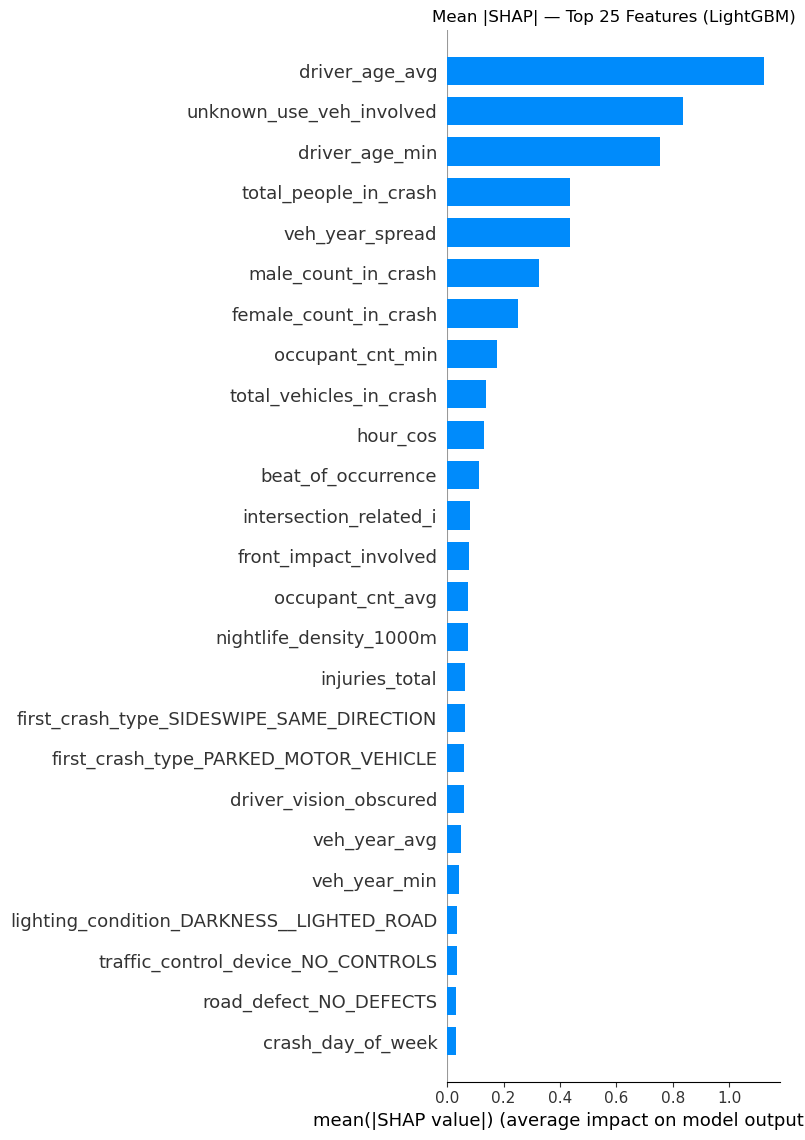

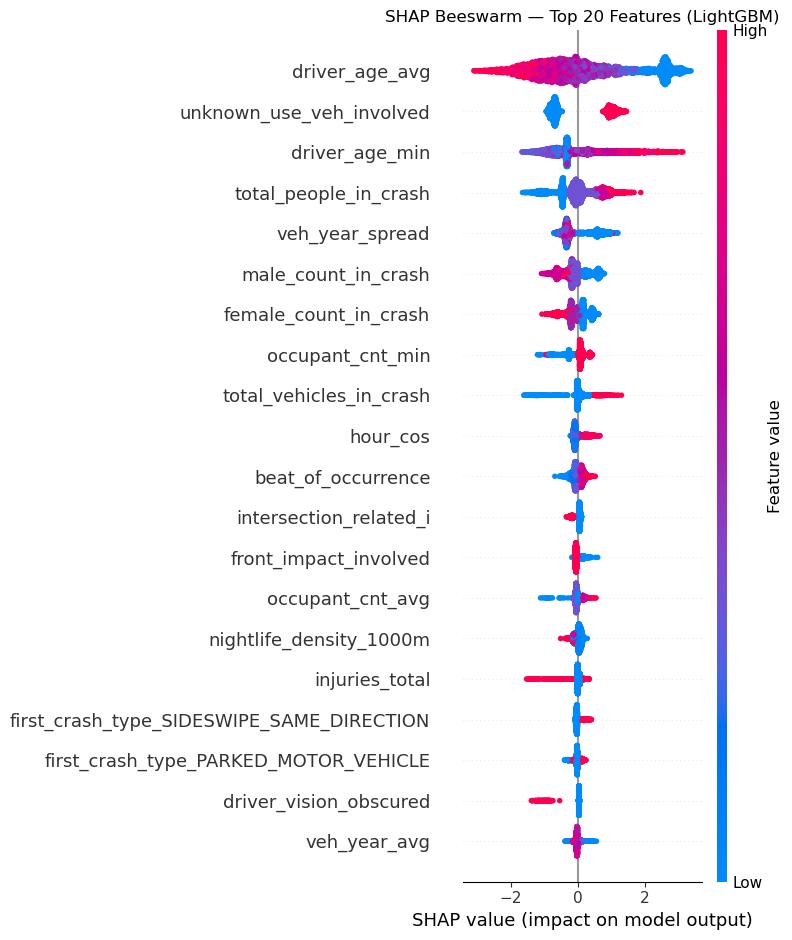

In [39]:
import shap
from lightgbm import LGBMClassifier

# ── Fit LightGBM on full train set (single fit for SHAP) ─────────────────────
lgbm_shap = Pipeline([
    ("prep",  preprocessor),
    ("model", LGBMClassifier(n_estimators=300, class_weight="balanced",
                              random_state=42, n_jobs=-1, verbose=-1)),
])
lgbm_shap.fit(X_train, y_train)

# ── Extract transformed feature matrix & names ───────────────────────────────
X_train_transformed = lgbm_shap[:-1].transform(X_train)
feature_names = X_train_transformed.columns.tolist()

# ── Compute SHAP values (TreeExplainer is fast for LightGBM) ─────────────────
explainer = shap.TreeExplainer(lgbm_shap["model"])
sample_idx = X_train_transformed.sample(5000, random_state=42).index
shap_values = explainer.shap_values(X_train_transformed.loc[sample_idx])

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

# ── Bar plot: mean |SHAP| per feature (top 25) ───────────────────────────────
shap.summary_plot(sv, X_train_transformed.loc[sample_idx],
                  feature_names=feature_names,
                  plot_type="bar", max_display=25, show=False)
plt.title("Mean |SHAP| — Top 25 Features (LightGBM)")
plt.tight_layout()
plt.savefig("imgs/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Beeswarm: direction + magnitude (top 20) ─────────────────────────────────
shap.summary_plot(sv, X_train_transformed.loc[sample_idx],
                  feature_names=feature_names,
                  max_display=20, show=False)
plt.title("SHAP Beeswarm — Top 20 Features (LightGBM)")
plt.tight_layout()
plt.savefig("imgs/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()